# Setup

In [ ]:
# STEPS

# Divide dataset into training and test samples ---> Train the classifier using training dataset ---> Test using sample data
# Performance metrics (Finalize the model)

In [4]:
#Setup

import sys
assert sys.version_info >= (3, 5)

import sklearn
assert sklearn.__version__ >= "0.20"

import numpy as np
import os

# To make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# WHere to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, 'images', CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("saving figure ", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format = fig_extension, dpi=resolution)

In [5]:
assert sklearn.__version__ >= "0.20"

def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.binary, interpolation="nearest")
    plt.axis("off")

# MNIST

In [6]:
#Download MNIST data
# Setting version as 1 as there might be many versions of mnist_784 dataset
# https://www.openml.org/d/554

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)

In [7]:
# print the keys
# A DESCR key describing the dataset
# A data key containing an array with one raw per instance and one column per feature
# A target key containing an array with the labels

mnist.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'DESCR', 'details', 'categories', 'url'])

In [8]:
# Getting data and label
# X --> data
# y --> label

X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

In [9]:
y.shape

(70000,)

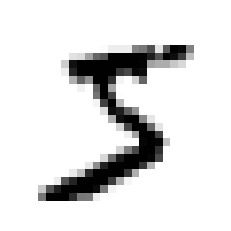

In [10]:
some_digit = X[0]
some_digit_image1 = plot_digit(some_digit)

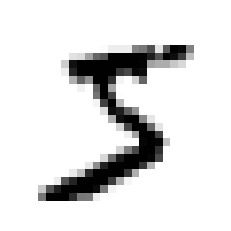

In [11]:
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")
plt.show()

In [12]:
y[0]

'5'

In [13]:
# cast y to integer. Labels (y) are string and most ML algorithm are expecting integers
import numpy as np

y = y.astype(np.uint8)
y

array([5, 0, 4, ..., 4, 5, 6], dtype=uint8)

In [14]:
X_train, X_test, y_train, y_test = X[:6000], X[6000:], y[:6000], y[6000:]
print(X_train.shape)

(6000, 784)


# Binary Classifier - Train 5-detector

In [15]:
# preparing training and test set for 5-detector

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)
print(y_test_5)
print(y_train_5)

[False False False ... False  True False]
[ True False False ... False False False]


In [16]:
# Lets train the model
# We will use Stochastic Gradient Descent (SGD) classifier
# This classifier has the advantage of being capable of handling very large datasets efficiently

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)


SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=None, penalty='l2',
              power_t=0.5, random_state=42, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)

In [17]:
# Lets see the prediction

sgd_clf.predict([some_digit])

array([ True])

# Performance Measures

## Measuring Accuracy Using Cross-Validation

In [18]:
# Measuring Accuracy using Cross-Validation

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.962 , 0.956 , 0.9665])

In [19]:
# Never5Classifier - Build a dump classifier that just classifies every single image in the "not-5" class

from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)
    print(np.zeros((len(X), 1), dtype=bool))

[[False]
 [False]
 [False]
 ...
 [False]
 [False]
 [False]]


In [20]:
# calculate accuracy using cross_val_score

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train, cv=3,scoring="accuracy")

array([0.0955, 0.094 , 0.1065])

## Confusion Matrix

In [21]:
#Get the predicted values

from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3) # try with never_5_clf to see the change in CM
print(y_train_pred)

[False False False ... False False False]


In [22]:
# y_train_pred = cross_val_predict(never_5_clf, X_train, y_train_5, cv=3) # try with never_5_clf to see the change in CM
# print(y_train_pred)

In [23]:
# Confusiom matrix of 5-detector
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)

array([[5375,  111],
       [ 120,  394]])

## Precision and Recall

In [24]:
# Get precision score of 5-detector

from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)

0.7801980198019802

In [25]:
# Get Recall score of 5-detector

recall_score(y_train_5, y_train_pred)

0.7665369649805448

In [26]:
# Get f1 score of 5-detector
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7733071638861628

## Precision/Recall Tradeoff

In [31]:
# Get Decision score of some_digit which is 5

y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([38042.34312442])

In [28]:
# Change threshold to 0 and see the prediction

threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [32]:
# Chnage threshold to 8000 and see the prediction

threshold = 80000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

### Plot Precision/Recall Curve

In [33]:
# Get the scores of all the training dataset using cross_val_predict with decision_function as method parameter

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method = "decision_function")

In [34]:
# Compute the precision and recall for all possible thresholds using precision_recall_curve()

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precisions.shape)
print("=============================================")
print(precisions)
print("=============================================")
print(recalls.shape)
print("=============================================")
print(recalls)
print("=============================================")
print(thresholds.shape)
print("=============================================")
print(thresholds)
# The last element of precision is 1 and recall is 0

(5170,)
[0.09943896 0.09926471 0.09928392 ... 1.         1.         1.        ]
(5170,)
[1.         0.99805447 0.99805447 ... 0.00389105 0.00194553 0.        ]
(5169,)
[-794281.25464331 -794223.78112917 -793338.36872556 ...  830440.47034494
  850868.83207321  852681.43917402]


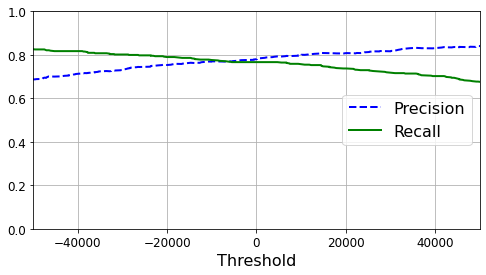

In [35]:
# plot both precision and recall for the thresholds using matplotlib
# Select the threshold value that gives the best precision/recall tradeoff to the task at hand.

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)
    plt.axis([-50000, 50000, 0, 1])
    
plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

### Build model with 90% Precision

In [36]:
# Lets say you decide to aim for 90% precision. You need to look for threshold which will give 90% precision

threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
threshold_90_precision
print('index =', np.argmax(precisions >= 0.90))
print('Precision = ', precisions[np.argmax(precisions>=0.90)])

index = 4845
Precision =  0.9012345679012346


In [37]:
# Get the predicted values with threshold which gives 90% precision

y_train_pred_90 = (y_scores >= threshold_90_precision)

In [38]:
# Calculate precision score

precision_score(y_train_5, y_train_pred_90)

0.9012345679012346

In [39]:
# Calculte recall score

recall_score(y_train_5, y_train_pred_90)

0.5680933852140078

# ROC Curve

In [53]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

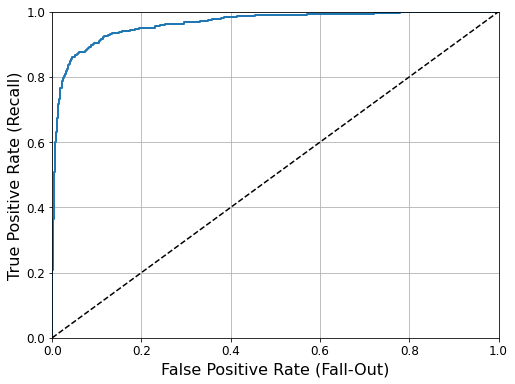

In [54]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0,1],[0,1], 'k--') # dashed diagonal
    plt.axis([0,1,0,1])
    plt.xlabel('False Positive Rate (Fall-Out)', fontsize=16)
    plt.ylabel('True Positive Rate (Recall)', fontsize=16)
    plt.grid(True)
    
plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

0.9641599203348885

In [56]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [57]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
print(y_probas_forest)
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

[[0.37 0.63]
 [0.98 0.02]
 [0.95 0.05]
 ...
 [0.67 0.33]
 [0.99 0.01]
 [0.9  0.1 ]]


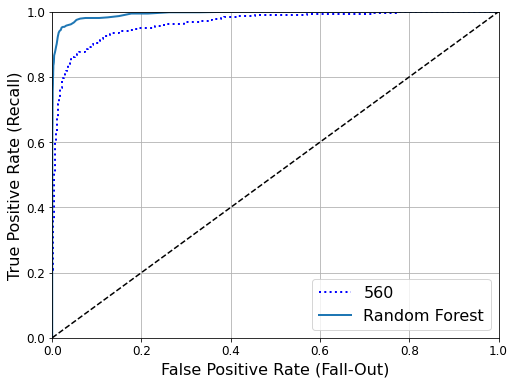

In [58]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, "b:", linewidth=2, label="560")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.grid(True)
plt.legend(loc="lower right", fontsize=16)
plt.show()

In [60]:
roc_auc_score(y_train_5, y_scores_forest)

0.9936162229715256

In [62]:
y_train_pred_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3)
precision_score(y_train_5, y_train_pred_forest)

0.9886363636363636

In [63]:
recall_score(y_train_5, y_train_pred_forest)

0.6770428015564203

# Multiclass Classification

In [65]:
# Multicalss Classification Using SGD Classifier
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])


array([5], dtype=uint8)

In [66]:
# Check accuracy using Cross Validation
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")


array([0.8565, 0.8715, 0.8635])

In [70]:
# Improving accuracy by scaling the features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf,X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8705, 0.8985, 0.8925])

# Multi-Label Classification

In [71]:
# Multilabel classifier to classify image in two labels
# Label 1 - If it is greater than 7
# Label 2 - If it is odd

from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)

y_multilabel = np.c_[y_train_large, y_train_odd]

In [72]:
# Train the model using KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

In [74]:
# Test the classifier

knn_clf.predict([some_digit])

array([[False,  True]])

# Multi-Output Classification

In [75]:
# Adding noise in training set

import numpy.random as rnd

noise_train = rnd.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise_train


# Adding noise in test set

noise_test = rnd.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise_test

# Setting clean image as the label (y_train and y_test)

y_train_mod = X_train
y_test_mod = X_test

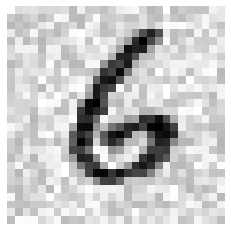

In [76]:
# View the noisy image

some_index = 0
plot_digit(X_test_mod[some_index])

In [77]:
# Let use clean the image using the Classifier

knn_clf.fit(X_train_mod, y_train_mod)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')

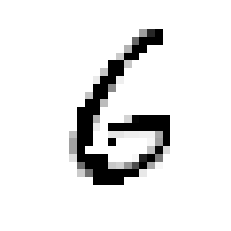

In [78]:
# View cleaned image

clean_digit = knn_clf.predict([X_test_mod[some_index]])
plot_digit(clean_digit)